# Data Storage in `pnmlib`

One of the main operations of any scientific software library is to read and write data pertaining to the simulation. Implied in that role is that the data is also stored by the library. A lot of thought (and experience) went into designing how `pnmlib` reads, writes and stores simulation data.  In this notebook we will outline all three of these operations.

## The Row-Column `RC` Format

The data storage format used by `pnmlib` is based on the familar spreadsheet, meaning that data is stored in *rows* and *columns*, hence it is called the `RC` format. The main objectives of the `RC` data storage format are: 

(a) **the data should be self-descriptive without extra metadata**, and

(b) **the data should be stored in the simplest way possible**

The first of these objectives can be accomplished by using a well-defined convention for the column names. The `pnmlib` naming convention is as follows:

`{group/}<prefix.property>{.subcategory}`

where the items in `< >` are required and those in `{ }` are optional. For example, the column named `network/throat.diameter` would contain the *diameter* values for all the *throats* in the *network*. With this convention it is obvious what data is stored in the column `water/pore.temperature`, which satisfies the self-descriptive aspect. Not only does the column name provide information about which values are stored there, but the *group* tells `pnmlib` how the simulation is structured.

To achieve the second goal of simplicity, `pnmlib` uses a standard Python dictionary (`dict`) to store data, where `keys` correspond to the column names, and the values are stored as `numpy.ndarrays`. Using a `dict` of `numpy.ndarrays` is more flexible than using a `pandas.DataFrame` and easier to use than advanced storage technologies like `hdf5` or `zarr`. `numpy.ndarrays` are also numerically efficient and familiar so makes an ideal choice on many fronts.

As well as meeting the above two objectives, the `rc` format has a number of *technical* advantages as well, but these will be discussed in a different notebook. The remainder of this notebook will explore the details and usage of the `RC` data storage in `pnmlib`.

## Basic Demonstration of the `RC` Format

Let's start by manually defining at 2-by-2 network:

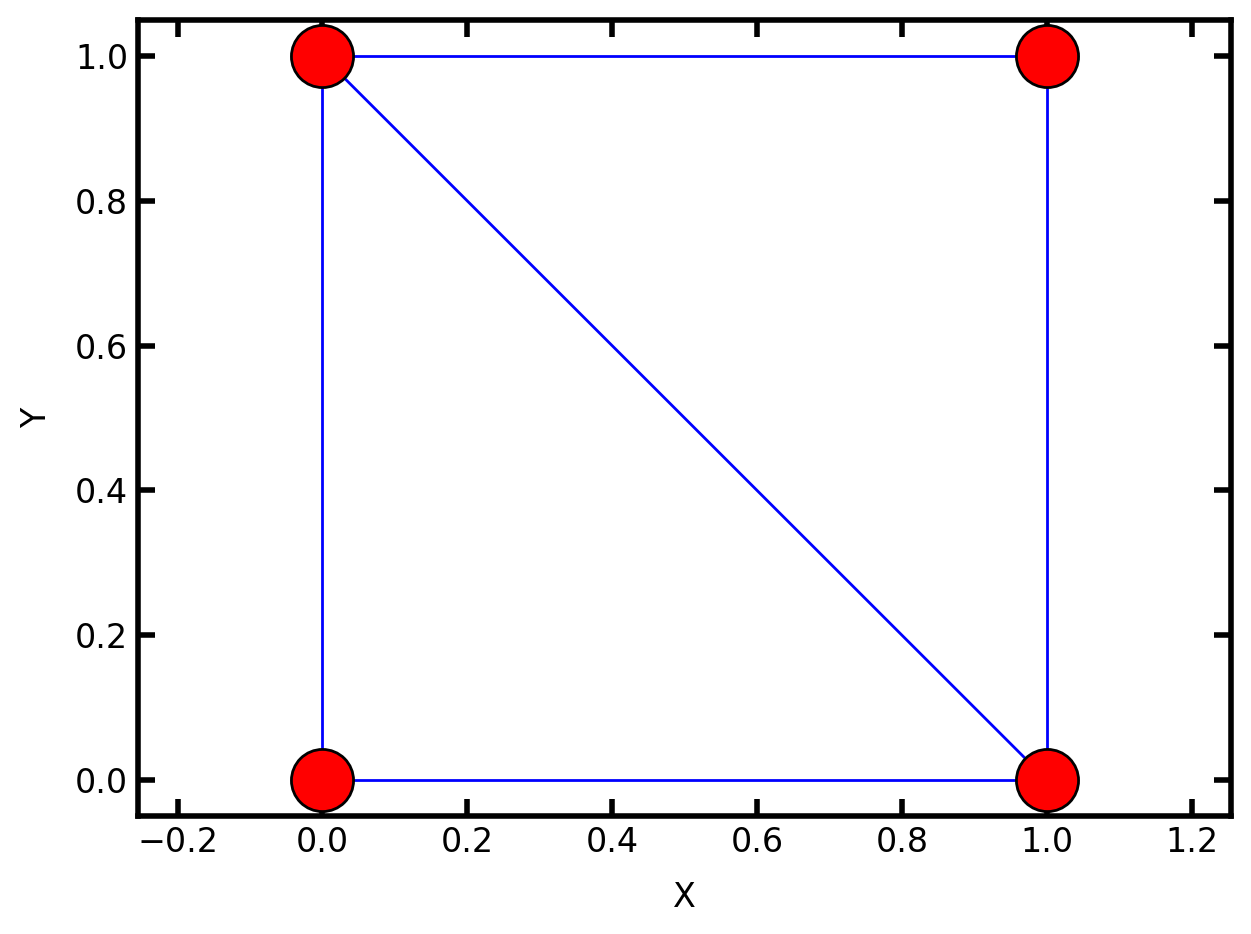

In [43]:
import pnmlib
import porespy as ps
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pnmlib.core import set_data, get_data
from pnmlib.inspect import tree
ps.visualization.set_mpl_style()

pn = {}
pn['pore.coords'] = np.vstack([[0, 0, 0], 
                               [0, 1, 0], 
                               [1, 0, 0], 
                               [1, 1, 0]])
pn['throat.conns'] = np.vstack([[0, 1], 
                                [0, 2], 
                                [1, 3], 
                                [2, 3],
                                [1, 2]])
ax = pnmlib.visualization.plot_edges(pn)
ax = pnmlib.visualization.plot_nodes(
    pn, 
    ax=ax,
    markersize=500, 
    zorder=2, 
    edgecolor='k',
)

Let's manually add some data to this network:

In [44]:
Np = 4  # Number of pores
Nt = 5  # Number of throats
pn['pore.diameter'] = np.random.rand(Np)
pn['pore.volume'] = np.pi/4*pn['pore.diameter']**2
pn['throat.diameter'] = np.random.rand(Nt)
pn['throat.length'] = np.ones(Nt)

We can convert the data on the network to a `pandas` DataFrame, which is 'spreadsheet-like' package in Python. One limitation of the DataFrame is that all columns must be the same length, which means that pore and throat data must be stored in separate tables.  We can view just the pore data:

In [45]:
df = pnmlib.inspect.props_to_df(pn, element='pore')

The resulting DataFrame has a nice default display format, so the self-descriptive nature of the format should be evident:

In [46]:
df

,pore.coords,pore.diameter,pore.volume
0,"[0, 0, 0]",0.722,0.409
1,"[0, 1, 0]",0.381,0.114
2,"[1, 0, 0]",0.876,0.602
3,"[1, 1, 0]",0.239,0.045


> **Warning: Spreadsheet Software Does Not Like Multidimensional Data**
> 
> Storing multidimensional data in a column causes most spreadsheet software to complain, or more likely to treat is as 'text'. When outputting data like `'pore.coords'` to an actual spreadsheet it needs to be further divided into `'pore.coords[0]'`, `'pore.coords[1]'`, etc.  The functions in the `io` module deal with this accordingly. 

We can do the same thing for throat data:

In [47]:
pnmlib.inspect.props_to_df(pn, element='throat')

,throat.conns,throat.diameter,throat.length
0,"[0, 1]",0.301,1.0
1,"[0, 2]",0.940,1.0
2,"[1, 3]",0.433,1.0
3,"[2, 3]",0.661,1.0
4,"[1, 2]",0.916,1.0


> **The Meaning of `'throat.conns'`**
>
> The values in the `'throat.conns'` array indicate which two pores are on either end of the throat, so throat `0` connects pores `0` and `1`. Keeping in mind that a pore's "index" is implied by its row. This is a deceptively simple format that is actually the sparse representation of the network's undirected adjacency matrix in 'COO' or 'IJV' format. 


### Summary of the `RC` Format

- Each column represents a different property of the pores and throats, like diameter or volume.
- Each row contains the properties of single pore or throat.
- The pore (or throat) index or identification number is implied by the row number on which that pore's data is stored, so when we talk about pore 0, we are refering to the pore whose data is stored on row 0.
- Multidimensional data like `'pore.coords'` is all stored in a single column. This is possible because we use `ndarrays` rather than actual columns.
- The column names must adhere to the convention.  Naming conventions are discussed further below.


## Reading and Writing Data: The Getter and Setter Functions

In order to keep things truly simple, `pnmlib` uses a *standard* python dictionary, with no subclassing.  However, the standard python dictionary has no ability to interpret the dictionary keys (i.e. check validity or modify behavior based on the key), so `pnmlib` is based on using "setter" and "getter" functions, `set_data` and `get_data`, to write and read data in the dictionary. For instance, the following two cases are equivalent:

In [50]:
rc = {}  # Standard python dictionary
rc['network/pore.diameter'] = 2.0*np.ones(4)
print(rc)

{'network/pore.diameter': array([2., 2., 2., 2.])}


And:

In [51]:
rc = {}
set_data(target=rc, key='network/pore.diameter', value=2.0*np.ones(4))
tree(rc)

└── network
│   └── 'pore.diameter': (4,) float64


The advantage (or necessity) of using the `set_data` method is not evident in the above demonstration, and in fact it looks unnecessarily verbose, but the main point is that these functions ultimately just read and and write to a dictionary. As we shall see they do quite a lot more than that. Of course, it is possible to write directly to the `dict`, so long as the naming convention and data format requirements are met. However, using the `set_data` function provides consistency checks on the data so is good practice. Similarly, it is also possible to retrieve data from the `dict` directly, but using `get_item` provides a number of useful features and shortcuts as we shall see.

## Naming Conventions: Valid Prefixes

Each dictionary key (i.e. column name) must be classified using one of the following prefixes:

* `'pore'`
* `'throat'`
* `'conduit'`
* `'param'`
* `'attr'`

These prefixes tell `pnmlib` what type of data is stored in each key as explained below.

### `pore` and `throat`

These refer to whether the array stored under the given key corresponds to pore or throat data. This is necessary to 

(a) differentiate between properties which may exist on both pores and throats, such as  diameter for example, and 

(b) to ensure that all arrays are a consistent length (i.e. all arrays starting with `'pore.'` must have the same number of rows as the network has pores).

In [8]:
set_data(rc, 'network/pore.diameter', np.ones(4))
set_data(rc, 'network/throat.diameter', np.ones(4))
tree(rc)

└── network
│   ├── 'pore.diameter': (4,) float64
│   └── 'throat.diameter': (4,) float64


This network therefore has 4 pores and 4 throats.  Any attempts to write arrays of different lengths will result in an error.

In [9]:
try:
    set_data(rc, 'network/pore.bar', np.ones(8))
except Exception as e:
    print(e)

Provided array is wrong length for network/pore.bar


### `conduit`

This is used to indicate an array that has the same number of rows as the network has throats, but is 3 columns wide.  The left and right columns contain data for the pores on each end of the throat, while the center column contains the throat data. For example, if throat `i` connects pores `j` and `k`, then row `i` of `conduit.diameter` will contain the diameters pore `j`, throat `i`, and pore `k` in each column respectively. 

In [10]:
set_data(rc, 'network/conduit.foo', np.ones((4, 3)))
tree(rc)

└── network
│   ├── 'conduit.foo': (4, 3) float64
│   ├── 'pore.diameter': (4,) float64
│   └── 'throat.diameter': (4,) float64




When writing `'conduit'` data this shape will be enforced, meaning that an error will occur if the array is not `Nt-by-3`.

In [11]:
try:
    set_data(rc, 'network/conduit.bar', np.ones((4, 2)))
except Exception as e:
    print(e)

conduit arrays must be 3 columns wide


### `param`

This is used to store numerical data that do not correspond to pore and throat locations, such as scalar values like barometric pressure or molecular weight:

In [12]:
set_data(rc, 'param.MW', 29.1)
tree(rc)

├── 'param.MW': 29.1
└── network
│   ├── 'conduit.foo': (4, 3) float64
│   ├── 'pore.diameter': (4,) float64
│   └── 'throat.diameter': (4,) float64


### `attr`

This is used to indicate any non-numerical data. This data should be serializable, meaning it can be written to disk if the entire structure is saved. Strings are a common example of serializable data, whereas instantiated objects are not.

In [13]:
set_data(rc, 'attr.name', 'foo')
tree(rc)

├── 'attr.name': foo
├── 'param.MW': 29.1
└── network
│   ├── 'conduit.foo': (4, 3) float64
│   ├── 'pore.diameter': (4,) float64
│   └── 'throat.diameter': (4,) float64


Attempting to use an unsupported prefix will result in an error:

In [14]:
try:
    set_data(rc, 'foo.bar', 1.0)
except Exception as e:
    print(e)

Unsupported prefix 'foo'


## Naming Conventions: Special Characters

In addition to the reserved keywords, there are reserved symbols as well. These include:

* `.`
* `/`
* `*`
* `@`
* `|`

These are explained in the following sections.

### Properties and the `.` Symbol

As is already illustrated above, the `.` is used to separate the `prefix` from the `property`, such as `'pore.diameter'`.  What's not illustrated is that the first `.` is *always* interpreted as the separation between the `prefix` and the `property`, while additional `.`'s are ignored.  This means that `.` can be optionally employed to create sub-properties, like `'pore.bc.rate'` and `'pore.bc.value'`.  

In [15]:
set_data(rc, 'algorithm/pore.bc.rate', np.zeros(4))
set_data(rc, 'algorithm/pore.bc.value', 1.2*np.ones(4))
tree(rc)

├── 'attr.name': foo
├── 'param.MW': 29.1
├── algorithm
│   ├── 'pore.bc.rate': (4,) float64
│   └── 'pore.bc.value': (4,) float64
└── network
│   ├── 'conduit.foo': (4, 3) float64
│   ├── 'pore.diameter': (4,) float64
│   └── 'throat.diameter': (4,) float64


### Groups and the `/` Symbol

It is common to have multiple fluids and algorithms in a given simulation, so these properties can be subcategorized to avoid collisions, like:

In [16]:
set_data(rc, 'water/pore.viscosity', 0.001*np.ones(4))
set_data(rc, 'air/pore.viscosity', 1.83e-5*np.ones(4))
tree(rc)

├── 'attr.name': foo
├── 'param.MW': 29.1
├── air
│   └── 'pore.viscosity': (4,) float64
├── water
│   └── 'pore.viscosity': (4,) float64
├── algorithm
│   ├── 'pore.bc.rate': (4,) float64
│   └── 'pore.bc.value': (4,) float64
└── network
│   ├── 'conduit.foo': (4, 3) float64
│   ├── 'pore.diameter': (4,) float64
│   └── 'throat.diameter': (4,) float64


This is also useful for separating algorithms, which are often numerous.

### Wildcards and the `*` Symbol

The `*` symbol is widely used as a wildcard in many software packages, meaning to match anything. In `pnmlib` it can be put at the end, for instance to find all the boundary conditions:

In [17]:
get_data(rc, 'algorithm/pore.bc.*')

{'algorithm/pore.bc.rate': array([0., 0., 0., 0.]),
 'algorithm/pore.bc.value': array([1.2, 1.2, 1.2, 1.2])}

Or it can go in the middle, in place of the `element`, for instance to find all the diameters:

In [18]:
get_data(rc, 'network/*.diameter')

{'network/pore.diameter': array([1., 1., 1., 1.]),
 'network/throat.diameter': array([1., 1., 1., 1.])}

Or it can go at the beginning to find a given property on all groups:

In [19]:
get_data(rc, '*/pore.viscosity')

{'water/pore.viscosity': array([0.001, 0.001, 0.001, 0.001]),
 'air/pore.viscosity': array([1.83e-05, 1.83e-05, 1.83e-05, 1.83e-05])}

### Domains and the `@` Symbol

Often times only a subset of the locations are of interest. If a label (a boolean array) has been generated for that location, like `'pore.left'`, then it can be used as part of the dictionary key to mask only those locations:

In [20]:
set_data(rc, 'network/pore.left', np.random.rand(4) > 0.5)
set_data(rc, 'network/pore.diameter@left', 4)
get_data(rc, 'network/pore.diameter')

array([1., 1., 1., 1.])

And it can be used in the `get_item`:

In [21]:
get_data(rc, 'network/pore.diameter@left')

array([], dtype=float64)

### Subgroups and the `|` Symbol

The naming convention in `pnmlib` can tend to create long dictionary keys.  Sometimes it is desired to have a sub-dictionary where the group information has been removed from the keys. In this case, the `|` symbol can be used in place of the `\` symbol, and anything preceding the `|` will be trimmed from the dictionary keys in the returned `dict`:

In [40]:
rc2 = get_data(rc, 'network|*')
tree(rc2)

├── 'conduit.foo': (4, 3) float64
├── 'pore.diameter': (4,) float64
├── 'pore.left': (4,) bool
└── 'throat.diameter': (4,) float64


The original `dict` remains unchanged. In fact, the arrays in the new `dict` are references the original ones, so changes to one place changes the other:

In [41]:
rc['network/pore.diameter'][0] = 2.0
print(rc2['pore.diameter'])

[2. 1. 1. 1.]


If a true copy is required, the `deepcopy` function from the `copy` module can be used:

In [42]:
from copy import deepcopy

rc3 = deepcopy(rc2)
rc['network/pore.diameter'][0] = 3.0
print(rc2['pore.diameter'])
print(rc3['pore.diameter'])

[2. 1. 1. 1.]
[3. 1. 1. 1.]


## Data Types: Numerical, Boolean, and Scalar

`pnmlib` distinguishes between numerical data (i.e. `float` and `int`) and Boolean data (i.e. `bool`).  The former are referred to as *properties* since they describe the physical properties of the pores and throast, like diameter.  The latter is referred to as a *label* since it is essentially a flag that indicates if a condition is true on a given pore or note. 

### Properties

Numerical data means things like `pn['pore.diameter']`, which is a vector full of numbers, either `float` or `int`.  These are referred to as *properties*, or *props*, because they represent the physical properties of the pores and throats.  

When writing property data to an object, it is important that we give a value to *every* element. Even if all the values are the same, we still require that each location have a value. For instance, a simulation may be isothermal, so `pn['pore.temperature']` is the same everywhere, but code is written to expect that tmperature might vary, so assumes such properties can vary by location.  

### Labels

Boolean data, `True` and `False` are treated as *labels*.  For example, a network may have an array called `'pore.left'`, with `True` values in all the pores that are on the left side of the network.  Like *property* arrays they must also be full length array with one value for each element.  It is common for most of the values to be `False`.  The power of this format is that boolean arrays can be used as masks to `numpy` arrays. So we can find the diameter of all the pores on the left face of the network using `pn['pore.diameter'][pn['pore.left']]`. 



## Additional Features of the `get_data` and `set_data` Functions

Not only do the `get_data` and `set_data` functions help enforce the naming convention, but they provide several additional convenient features.

### Deleting Items by Assigning `None`

### Broadcasting Scalars to Each Location

### Returning Numerical Keys Directly

### Unpacking Dictionaries